## Breast Cancer Prediction using Various Machine Learning Models

This notebook demonstrates a machine learning pipeline for predicting breast cancer based on various features. It covers data loading, preprocessing, feature selection using Variance Inflation Factor (VIF) and Recursive Feature Elimination (RFE), and training multiple models including Logistic Regression, Decision Tree Regressor, and Linear Regression. Finally, the models are evaluated and compared using metrics like accuracy, confusion matrix, classification report, and Mean Squared Error (MSE).

### 1. Library Imports

This section imports all the necessary libraries for data manipulation, visualization, machine learning models, and evaluation.

The code cell below imports `numpy` for numerical operations, `pandas` for data handling, `seaborn` and `matplotlib.pyplot` for data visualization, `RFE` for feature selection, `StandardScaler` for feature scaling (though not used in this execution, it's typically for feature scaling), `variance_inflation_factor` for VIF calculation, `train_test_split` for splitting data, and `LinearRegression`, `DecisionTreeRegressor` for model building.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

### 2. Data Loading and Initial Inspection

Here, the dataset is loaded from a CSV file into a pandas DataFrame, and its initial structure is inspected.

In [ ]:
df = pd.read_csv('cancer data.csv')

In [ ]:
print(df.head(5))
print(df.shape)

         ID  radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    842302    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    842517    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2  84300903    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3  84348301    11.42     20.38       77.58   386.1      0.14250       0.28390   
4  84358402    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  ...  texture3  perimeter3   area3  \
0      0.3001          0.14710     0.2419  ...     17.33      184.60  2019.0   
1      0.0869          0.07017     0.1812  ...     23.41      158.80  1956.0   
2      0.1974          0.12790     0.2069  ...     25.53      152.50  1709.0   
3      0.2414          0.10520     0.2597  ...     26.50       98.87   567.7   
4      0.1980          0.10430     0.1809  ...     16.67      152.20  1575.0   

   smoothness3  compactness3  co

### 3. Data Preprocessing: Label Encoding

The target variable 'Diagnosis' is converted from categorical (M/B) to numerical (0/1) format.

The `Diagnosis` column, which is likely categorical (e.g., 'M' for Malignant, 'B' for Benign), is converted into numerical representation (0 and 1) using `LabelEncoder`. This is necessary for most machine learning models.

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Diagnosis'] = label_encoder.fit_transform(df['Diagnosis'])

### 4. Exploratory Data Analysis: Correlation Heatmap

A heatmap is generated to visualize the correlation matrix between all features, helping to understand relationships and identify highly correlated features.

<Axes: >

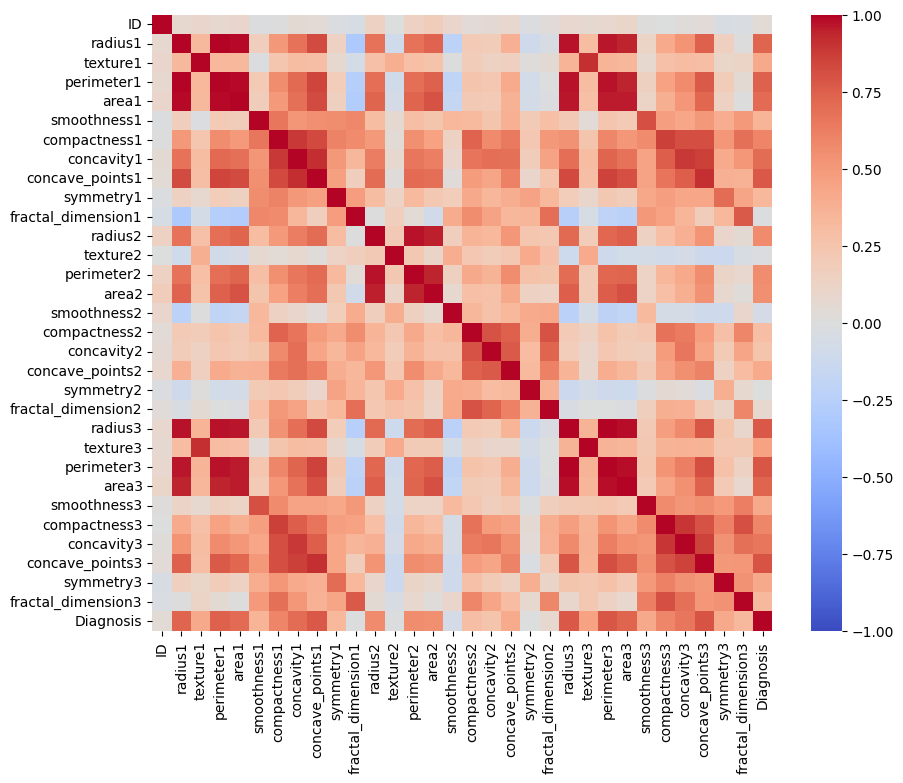

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), vmin = -1 , vmax = +1 , cmap = 'coolwarm')

In [ ]:
df1 = df.iloc[:, 1:-1]
print(df1.head())
print(df1.shape)

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

### 5. Feature Selection: Variance Inflation Factor (VIF)

Highly correlated features (multicollinearity) can negatively impact model performance. VIF is used to identify and remove such features iteratively.

In [ ]:
def calculate_vif(df1):
  vif = pd.DataFrame()
  vif['Features'] = df1.columns
  vif['vif_values'] = [variance_inflation_factor(df1.values, i) for i in range (df1.shape[1])]
  return vif


max_vif = 10
remove_flag = True

while remove_flag:
    vif = calculate_vif(df1)
    max_vif_feature = vif.loc[vif['vif_values'].idxmax()]

    if max_vif_feature['vif_values'] > max_vif:
        print(f'Removing column: {max_vif_feature["Features"]} with VIF: {max_vif_feature["vif_values"]}')
        df1 = df1.drop(max_vif_feature["Features"], axis=1)
    else:
        remove_flag = False

Removing column: radius1 with VIF: 63306.17203588469
Removing column: radius3 with VIF: 7573.943486033555
Removing column: perimeter1 with VIF: 3901.901687119607
Removing column: perimeter3 with VIF: 668.3854404127386
Removing column: fractal_dimension1 with VIF: 508.08682464149285
Removing column: smoothness3 with VIF: 368.0533791867144
Removing column: texture3 with VIF: 309.54444960438434
Removing column: fractal_dimension3 with VIF: 184.67972071700538
Removing column: symmetry3 with VIF: 167.30971478504884
Removing column: concavity1 with VIF: 142.29904340088856
Removing column: radius2 with VIF: 104.99215955661566
Removing column: concave_points3 with VIF: 100.94649021325061
Removing column: smoothness1 with VIF: 86.99658368431041
Removing column: compactness1 with VIF: 74.72314541276282
Removing column: area1 with VIF: 67.47169344522399
Removing column: compactness3 with VIF: 49.02308700997905
Removing column: perimeter2 with VIF: 43.72833047786977
Removing column: symmetry1 with

### 6. Model Preparation: Data Splitting

The dataset is split into training and testing sets to evaluate model performance on unseen data.

This cell imports the `LogisticRegression` model from scikit-learn and initializes an instance of it. Logistic Regression is a classification algorithm used here to predict the binary 'Diagnosis' outcome.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [ ]:
df1.head()

,texture2,area2,smoothness2,concavity2,symmetry2,fractal_dimension2,concavity3
0,0.9053,153.40,0.006399,0.05373,0.03003,0.006193,0.7119
1,0.7339,74.08,0.005225,0.01860,0.01389,0.003532,0.2416
2,0.7869,94.03,0.006150,0.03832,0.02250,0.004571,0.4504
3,1.1560,27.23,0.009110,0.05661,0.05963,0.009208,0.6869
4,0.7813,94.44,0.011490,0.05688,0.01756,0.005115,0.4000


### 7. Model Training and Evaluation: Logistic Regression

Train a Logistic Regression model and evaluate its performance using accuracy, confusion matrix, and classification report.

In [ ]:
X = df1
Y = df['Diagnosis']
x_train, x_test, y_train, y_test = train_test_split(X, Y, train_size=0.7, random_state=12)

In [ ]:
lr.fit(x_train , y_train)
y_pred = lr.predict(x_test)
lr.score(x_test , y_test)

0.8830409356725146

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import classification_report
cm = confusion_matrix(y_test , y_pred)
print(cm)
print(classification_report(y_test , y_pred))

[[101   6]
 [ 14  50]]
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       107
           1       0.89      0.78      0.83        64

    accuracy                           0.88       171
   macro avg       0.89      0.86      0.87       171
weighted avg       0.88      0.88      0.88       171



### 8. Feature Selection (RFE) and Decision Tree Regressor

Recursive Feature Elimination (RFE) is applied with a Decision Tree Regressor to select the most important features, followed by training and evaluating the Decision Tree Regressor model.

In [ ]:
model = DecisionTreeRegressor(max_depth=5, random_state=42)

# create the RFE model and select the top 7 features
rfe = RFE(estimator=model, n_features_to_select=7)
rfe.fit(x_train, y_train)

# get the selected features
selected_features = x_train.columns[rfe.support_]
print("Selected Features: ", selected_features)

# rank the features by importance
feature_ranking = pd.DataFrame({'Feature': x_train.columns, 'Rank': rfe.ranking_})
print(feature_ranking.sort_values(by='Rank'))

Selected Features:  Index(['texture2', 'area2', 'smoothness2', 'concavity2', 'symmetry2',
       'fractal_dimension2', 'concavity3'],
      dtype='object')
              Feature  Rank
0            texture2     1
1               area2     1
2         smoothness2     1
3          concavity2     1
4           symmetry2     1
5  fractal_dimension2     1
6          concavity3     1


In [ ]:
model.fit(x_train , y_train)
y_pred = model.predict(x_test)
model.score(x_test , y_test)

0.5508725175233644

### 9. Linear Regression and R-squared Score Comparison

Train a Linear Regression model and compare its R-squared score with the Decision Tree Regressor.

In [ ]:
lr_model = LinearRegression()
lr_model.fit(x_train, y_train)
lr_score = lr_model.score(x_test, y_test)
print(f'Linear Regression Model Score: {lr_score}')

# Decision Tree Regressor score from previous execution
dt_score = model.score(x_test, y_test)
print(f'Decision Tree Regressor Model Score: {dt_score}')

if lr_score > dt_score:
    print('The Linear Regression model performed better than the Decision Tree Regressor.')
elif dt_score > lr_score:
    print('The Decision Tree Regressor model performed better than the Linear Regression model.')
else:
    print('Both models performed similarly.')

Linear Regression Model Score: 0.5268080221393128
Decision Tree Regressor Model Score: 0.5508725175233644
The Decision Tree Regressor model performed better than the Linear Regression model.


### 10. Mean Squared Error (MSE) Comparison

Calculate and compare the Mean Squared Error (MSE) for Logistic Regression, Linear Regression, and Decision Tree Regressor to determine the best-performing model based on this metric.

In [ ]:
from sklearn.metrics import mean_squared_error

# Linear Regression MSE
lr_y_pred = lr_model.predict(x_test)
lr_mse = mean_squared_error(y_test, lr_y_pred)
print(f'Linear Regression Model MSE: {lr_mse}')

# Decision Tree Regressor MSE
dt_y_pred = model.predict(x_test)
dt_mse = mean_squared_error(y_test, dt_y_pred)
print(f'Decision Tree Regressor Model MSE: {dt_mse}')

# Logistic Regression MSE
log_reg_y_pred = lr.predict(x_test)
log_reg_mse = mean_squared_error(y_test, log_reg_y_pred)
print(f'Logistic Regression Model MSE: {log_reg_mse}')

# Compare all three models based on MSE
min_mse = min(lr_mse, dt_mse, log_reg_mse)

if min_mse == lr_mse:
    print('The Linear Regression model performed best (lowest MSE) among the three models.')
elif min_mse == dt_mse:
    print('The Decision Tree Regressor model performed best (lowest MSE) among the three models.')
else:
    print('The Logistic Regression model performed best (lowest MSE) among the three models.')

Linear Regression Model MSE: 0.11081764181765281
Decision Tree Regressor Model MSE: 0.10518193632228721
Logistic Regression Model MSE: 0.11695906432748537
The Decision Tree Regressor model performed best (lowest MSE) among the three models.


### 11. Visualization: Logistic Regression Confusion Matrix

Visualize the confusion matrix for the Logistic Regression model using a heatmap.

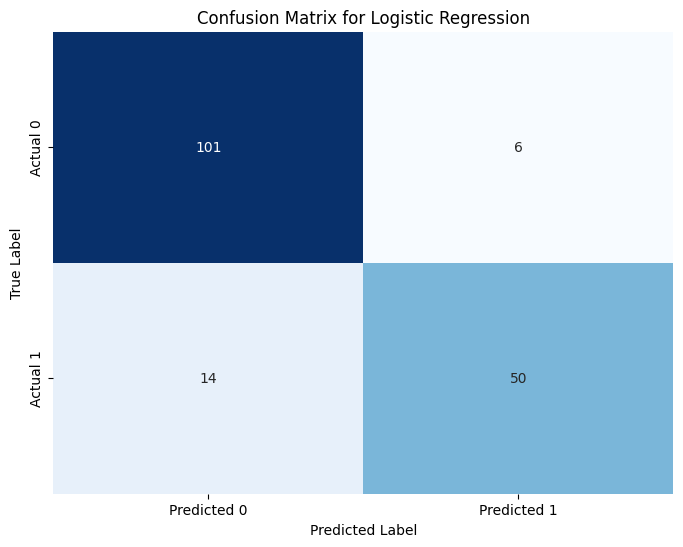

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 12. Visualization: Model MSE Comparison Bar Plot

Visualize the Mean Squared Error (MSE) of all three models using a bar plot for easy comparison.

/tmp/ipython-input-476/2547253104.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=mse_df, palette='viridis')


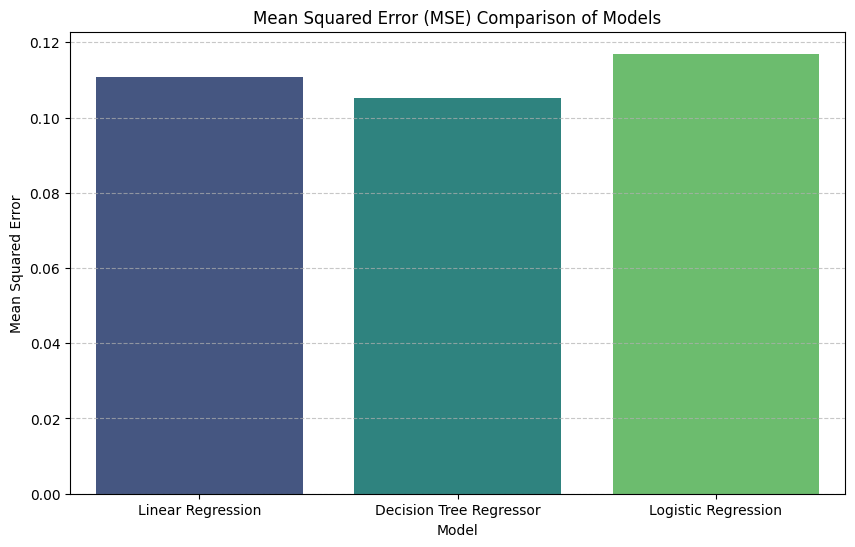

In [ ]:
mse_scores = {
    'Linear Regression': lr_mse,
    'Decision Tree Regressor': dt_mse,
    'Logistic Regression': log_reg_mse
}
mse_df = pd.DataFrame(list(mse_scores.items()), columns=['Model', 'MSE'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MSE', data=mse_df, palette='viridis')
plt.title('Mean Squared Error (MSE) Comparison of Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()